# День 08. Упражнение 03
# Переобучение

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
import joblib

## 1. Предобработка

1. Прочитай файл `dayofweek.csv` в DataFrame.
2. Используя `train_test_split` с параметрами `test_size=0.2`, `random_state=21`, получи `X_train`, `y_train`, `X_test`, `y_test`.
3. С помощью, например, `value_counts()` проверь, похожее ли распределение классов в train и test.
4. Добавь параметр `stratify=` и проверь распределение снова — теперь оно должно быть более-менее одинаковым в обоих наборах данных.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')

In [3]:
X = df.drop(columns=['dayofweek']).values
y = df['dayofweek'].values
feature_names = list(df.drop(columns=['dayofweek']).columns)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

In [5]:
print('Train distribution:', pd.Series(y_train).value_counts().sort_index().values)
print('Test distribution:', pd.Series(y_test).value_counts().sort_index().values)

Train distribution: [105 222 125 313  80 216 287]
Test distribution: [31 52 24 83 24 55 69]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

In [7]:
print('Train distribution:', pd.Series(y_train).value_counts().sort_index().values)
print('Test distribution:', pd.Series(y_test).value_counts().sort_index().values)

Train distribution: [109 219 119 316  83 217 285]
Test distribution: [27 55 30 80 21 54 71]


## 2. Базовые модели

1. Обучи те же самые базовые модели из предыдущего упражнения и вычисли accuracy, используя тестовый набор данных со стратификацией.
2. Все ли модели показали похожие значения метрики? Какая из них показала наибольшее отличие по сравнению с предыдущим упражнением? Напиши ответ в markdown-ячейке в конце раздела.

### a. Логистическая регрессия

In [8]:
lr = LogisticRegression(random_state=21, fit_intercept=False, max_iter=10000, solver='saga')
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` par

In [9]:
pred_lr = lr.predict(X_test)
print(accuracy_score(y_test, pred_lr))

0.6272189349112426


### b. SVM

In [10]:
svc = SVC(kernel='linear', random_state=21)
svc.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",21
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [11]:
pred_svc = svc.predict(X_test)
print(accuracy_score(y_test, pred_svc))

0.7159763313609467


### c. Дерево решений

In [12]:
dt = DecisionTreeClassifier(max_depth=4, random_state=21)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [13]:
pred_dt = dt.predict(X_test)
print(accuracy_score(y_test, pred_dt))

0.5295857988165681


### d. Случайный лес

In [14]:
rf = RandomForestClassifier(n_estimators=50, max_depth=25, random_state=21)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [15]:
pred_rf = rf.predict(X_test)
print(accuracy_score(y_test, pred_rf))

0.9289940828402367


random forest

c

## 3. Кросс-валидация

Можно было бы "поиграть" с параметрами модели, чтобы добиться более высокой точности на тестовом наборе, но так делать не принято. Такая тактика снова приводит к переобучению. Тестовый набор предназначен только для финальной проверки качества модели.

Однако есть другой способ решения этой задачи — кросс-валидация. Он не использует тестовый набор, а создает дополнительное разбиение обучающего набора. Существует несколько способов реализации, но общая идея одна: появляется валидационный набор, который используется для подбора гиперпараметров.

1. Используя `cross_val_score` с параметром `cv=10`, вычисли среднее значение accuracy и стандартное отклонение для каждой модели, использованной ранее (логистическая регрессия с `solver='liblinear'`, SVC, дерево решений, случайный лес).

### a. Логистическая регрессия

In [16]:
lr_cv = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=21, max_iter=10000))

In [17]:
scores = cross_val_score(lr_cv, X_train, y_train, cv=10)
print(f'{scores.mean():.4f} +/- {scores.std():.4f}')

0.5927 +/- 0.0199


### b. SVM

In [18]:
svc_cv = SVC(kernel='linear', random_state=21)

In [19]:
scores = cross_val_score(svc_cv, X_train, y_train, cv=10)
print(f'{scores.mean():.4f} +/- {scores.std():.4f}')

0.6587 +/- 0.0436


### c. Дерево решений

In [20]:
dt_cv = DecisionTreeClassifier(max_depth=4, random_state=21)

In [21]:
scores = cross_val_score(dt_cv, X_train, y_train, cv=10)
print(f'{scores.mean():.4f} +/- {scores.std():.4f}')

0.5089 +/- 0.0319


### d. Случайный лес

In [22]:
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)

In [23]:
scores = cross_val_score(rf_cv, X_train, y_train, cv=10)
print(f'{scores.mean():.4f} +/- {scores.std():.4f}')

0.9125 +/- 0.0175


## 4. Оптимизация

1. Выбери лучшую модель и немного поиграй с её параметрами на кросс-валидации, чтобы найти достаточно хорошие параметры или их комбинацию.
2. Вычисли accuracy для финальной модели на тестовом наборе данных.
3. Построй график, отображающий 10 самых важных признаков для этой модели.
4. Сохрани модель с помощью `joblib`.
5. Загрузи модель, сделай предсказания для тестового набора и вычисли accuracy.

In [24]:
best_rf = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=21)
scores = cross_val_score(best_rf, X_train, y_train, cv=10)
print(f'CV: {scores.mean():.4f} +/- {scores.std():.4f}')

CV: 0.9177 +/- 0.0180


In [25]:
best_rf.fit(X_train, y_train)
pred_best = best_rf.predict(X_test)
print(accuracy_score(y_test, pred_best))

0.9349112426035503


In [26]:
def plot_top_features(importances, feature_names, top_n=10):
    indices = np.argsort(importances)[::-1][:top_n][::-1]
    names = [feature_names[i] for i in indices]
    vals = [importances[i] for i in indices]
    plt.figure(figsize=(8, 5))
    plt.barh(range(top_n), vals, tick_label=names)
    plt.gca().invert_yaxis()
    plt.xlabel('Feature importance')
    plt.title(f'Top {top_n} most important features')
    plt.tight_layout()
    plt.show()
    print(f'Top-1: {feature_names[np.argmax(importances)]}')

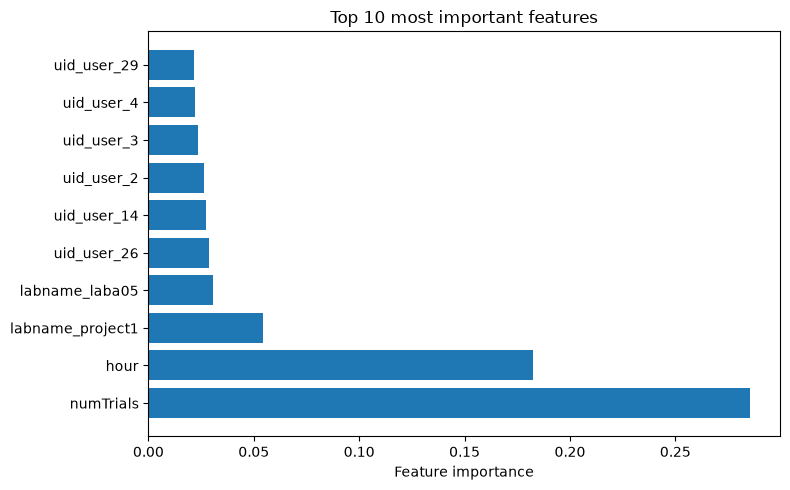

Top-1: numTrials


In [27]:
plot_top_features(best_rf.feature_importances_, feature_names, 10)

In [28]:
joblib.dump(best_rf, 'best_model.joblib')

['best_model.joblib']

In [29]:
loaded_model = joblib.load('best_model.joblib')
pred_loaded = loaded_model.predict(X_test)
print(accuracy_score(y_test, pred_loaded))

0.9349112426035503
